<a href="https://colab.research.google.com/github/JorgeRf07/Diplomado-Redes-Neuronales-Artificiales/blob/main/Practica_4_Pronostico_Redes_Neuronales_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###En esta práctica se abordará el pronóstico de una serie temporal mediante una red neuronal recurrente simple, conocida como RNN. Este tipo de red se caracteriza por tener memoria interna, lo que le permite considerar información de pasos anteriores para generar una predicción.

###La serie temporal utilizada será generada de manera artificial mediante una función senoidal. Esta función permitirá observar un comportamiento repetitivo y continuo, adecuado para comprender cómo la red aprende patrones temporales.

In [217]:
import numpy as np
import matplotlib.pyplot as plt

In [218]:
tiempo = np.linspace(0, 20, 200)
serie = np.sin(tiempo)

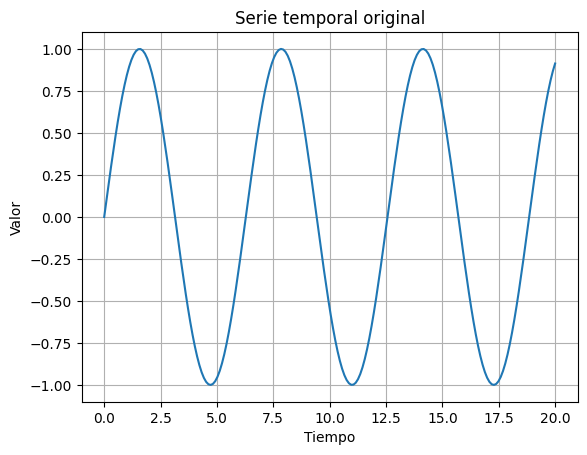

In [219]:
plt.plot(tiempo, serie)
plt.title("Serie temporal original")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.grid(True)
plt.show()

In [247]:
def crear_secuencias(serie, pasos):
  X = []
  y = []
  for i in range(len(serie) - pasos):
    X.append(serie[i:i + pasos])
    y.append(serie[i + pasos])
  return np.array(X), np.array(y)

pasos = 5
X, y = crear_secuencias(serie, pasos)
X = X.reshape(X.shape[0], X.shape[1], 1)
y = y.reshape(-1, 1)

##y_predicha = (h_t * Why) + by

#La función tangente hiperbólica permite transformar los valores de la red
#y ayuda a procesar información no lineal.
def tanh(x):
    return np.tanh(x)
    #También se necesita su derivada para realizar la actualización de parámetros:
def derivada_tanh(x):
  return 1 - x ** 2

###ℎ𝑡 = 𝑡𝑎𝑛ℎ((𝑥_𝑡 ∗ 𝑊𝑥ℎ) + (ℎ_𝑎𝑛𝑡𝑒𝑟𝑖𝑜𝑟 ∗ 𝑊ℎℎ) + 𝑏ℎ)

##Donde:
• x_t es la entrada en el instante actual.
• h_t es el estado oculto actual.
• h_anterior es el estado oculto del instante anterior.
• Wxh son los pesos entre la entrada y el estado oculto.
• Whh son los pesos recurrentes del estado oculto.
• bh es el sesgo de la capa oculta.
• tanh es la función de activación.
La salida final se calcula así:
y_predicha = (h_t * Why) + by
##Donde:
• Why son los pesos entre el estado oculto y la salida.
• by es el sesgo de salida.

In [248]:
np.random.seed(42)
neuronas_entrada = 1
neuronas_ocultas = 8
neuronas_salida = 1
Wxh = np.random.randn(neuronas_entrada, neuronas_ocultas) * 0.1
Whh = np.random.randn(neuronas_ocultas, neuronas_ocultas) * 0.1
Why = np.random.randn(neuronas_ocultas, neuronas_salida) * 0.1

bh = np.zeros((1, neuronas_ocultas))
by = np.zeros((1, neuronas_salida))

In [249]:
#La propagación hacia adelante de la RNN procesa una secuencia completa
#y genera una predicción final.

def propagacion_adelante_rnn(secuencia, Wxh, Whh, Why, bh, by):
    h = np.zeros((1, Whh.shape[0]))
    estados = []

    for t in range(len(secuencia)):
        x_t = secuencia[t].reshape(1, 1)
        h = tanh(np.dot(x_t, Wxh) + np.dot(h, Whh) + bh)
        estados.append(h)

    y_predicha = np.dot(h, Why) + by

    return y_predicha, estados

  #Esta función recibe una secuencia de entrada, procesa cada valor
  #y devuelve el pronóstico generado por la red.



In [250]:
#Para medir el error del pronóstico se utilizará el error cuadrático medio.
def calcular_error(y_real, y_predicha):
    return np.mean((y_real - y_predicha) ** 2)

In [251]:
def entrenar_rnn(X, y, Wxh, Whh, Why, bh, by, tasa_aprendizaje, epocas):
    errores = []

    for epoca in range(epocas):
        error_total = 0

        for i in range(len(X)):
            secuencia = X[i]
            valor_real = y[i].reshape(1, 1)

            y_predicha, estados = propagacion_adelante_rnn(
                secuencia,
                Wxh,
                Whh,
                Why,
                bh,
                by
            )

            error = valor_real - y_predicha
            error_total = error_total + np.mean(error ** 2)

            h_final = estados[-1]

            Why = Why + tasa_aprendizaje * np.dot(h_final.T, error)
            by = by + tasa_aprendizaje * error

            ajuste_oculto = np.dot(error, Why.T) * derivada_tanh(h_final)

            ultimo_valor = secuencia[-1].reshape(1, 1)

            Wxh = Wxh + tasa_aprendizaje * np.dot(ultimo_valor.T, ajuste_oculto)
            bh = bh + tasa_aprendizaje * ajuste_oculto

        error_promedio = error_total / len(X)
        errores.append(error_promedio)



        if epoca % 100 == 0:
            print("Época:", epoca, "Error:", error_promedio)

    return Wxh, Whh, Why, bh, by, errores
#Esta función permite entrenar la red neuronal recurrente de manera básica.
#Aunque se trata de una versión simplificada, permite comprender el principio
#del pronóstico secuencial.

tasa_aprendizaje = 0.01
epocas = 1000





In [252]:
Wxh, Whh, Why, bh, by, errores = entrenar_rnn(
      X,
      y,
      Wxh,
      Whh,
      Why,
      bh,
      by,
      tasa_aprendizaje,
      epocas
      )

Época: 0 Error: 0.42804888152224335
Época: 100 Error: 0.0041845592234373745
Época: 200 Error: 0.0034741681220812805
Época: 300 Error: 0.0028887260251379745
Época: 400 Error: 0.0024143444295603987
Época: 500 Error: 0.0020357296016952266
Época: 600 Error: 0.0017357489513246355
Época: 700 Error: 0.0014981714405162337
Época: 800 Error: 0.0013094220011629458
Época: 900 Error: 0.0011585660698575464


In [253]:

for i in range(len(X)):
    y_predicha, estados = propagacion_adelante_rnn(
        X[i],
        Wxh,
Whh,
Why,
bh,
by
)
pronosticos.append(y_predicha[0, 0])
pronosticos = np.array(pronosticos)

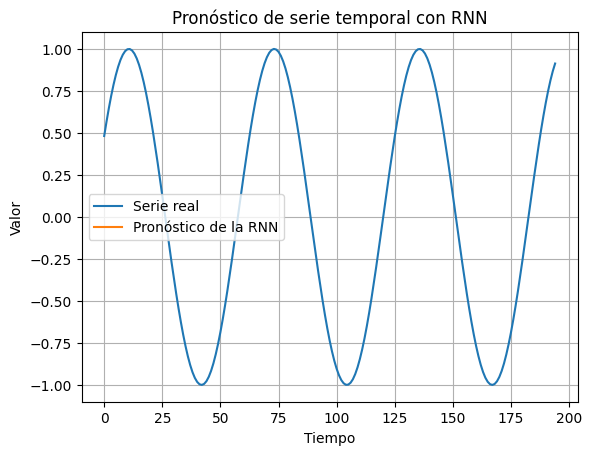

In [254]:
plt.plot(y, label="Serie real")
plt.plot(pronosticos, label="Pronóstico de la RNN")
plt.title("Pronóstico de serie temporal con RNN")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()

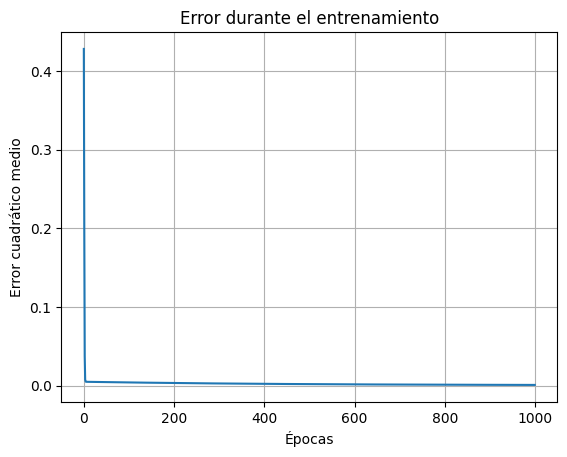

In [255]:
plt.plot(errores)
plt.title("Error durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Error cuadrático medio")
plt.grid(True)
plt.show()

In [256]:
ultima_secuencia = serie[-pasos:].reshape(pasos, 1)
siguiente_valor, estados = propagacion_adelante_rnn(
ultima_secuencia,
Wxh,
Whh,
Why,
bh,
by
)
print("Últimos valores utilizados:")
print(ultima_secuencia.flatten())
print("Pronóstico del siguiente valor:")
print(siguiente_valor[0, 0])

Últimos valores utilizados:
[0.68049212 0.75057812 0.81308908 0.86739415 0.91294525]
Pronóstico del siguiente valor:
0.926309355695525


1. ¿Qué es una serie temporal?
Una serie temporal es un conjunto de observaciones registradas de manera
secuencial, donde el orden de los datos es importante.
2. ¿Qué significa realizar un pronóstico?
Estimar valores futuros a partir de datos anteriores.
3. ¿Cuál es la diferencia entre clasificación, ajuste de funciones y pronóstico?
Clasificación: asigna datos a diferentes categorías o clases.
Ajuste de funciones: busca que una red aprenda la relación entre variables para aproximar una función.
Pronóstico: busca estimar valores futuros utilizando información anterior, especialmente cuando los datos tienen un orden temporal.
4. ¿Qué tipo de red neuronal se utilizó en esta práctica?
Red neuronal recurrente simple RNN. Fue implementada mediante funciones propias en Python, sin utilizar TensorFlow, Keras o PyTorch.
5. ¿Por qué una RNN es útil para datos secuenciales?
Una RNN tiene memoria interna y utiliza información de pasos anteriores para realizar la predicción actual. Esto es útil cuando existe una dependencia temporal entre los datos, es decir, cuando los valores futuros pueden depender de los valores observados anteriormente.
6. ¿Qué representa el estado oculto en una RNN?
Información que la red conserva de los pasos anteriores de la secuencia, en cada instante, el estado oculto anterior influye en el cálculo del estado oculto actual.
7. ¿Para qué se utilizan los pesos recurrentes Whh?
Conectan el estado oculto anterior con el estado oculto actual, permiten que la información de pasos anteriores influya en el procesamiento de la entrada actual.
8. ¿Qué función cumple la tasa de aprendizaje?
Determina qué tan grandes son los ajustes que se realizan a los parámetros de la red durante el entrenamiento.
9. ¿Qué mide el error cuadrático medio?
Mide la diferencia entre los valores reales y los valores pronosticados.


10. ¿Qué representa la gráfica de la serie real y el pronóstico?
Compara los valores reales de la serie temporal con los valores pronosticados, permite observar visualmente qué tan bien la red logró seguir el comportamiento de la serie.
11. ¿La red neuronal logró pronosticar correctamente la serie temporal? Justifica tu respuesta.
Sí, se considera que la red logró pronosticar la serie temporal si la gráfica del pronóstico se parece a la serie real y el error disminuye durante el entrenamiento.